# Hands-On: Build a Hand Gesture Recogniser

Earlier, we used a pretrained CNN (MobileNetV2) to classify images.

We then explored how Computer Vision can go beyond classification,
using object detection, segmentation and keypoint detection.

Now, let's bring these ideas together!

**Our challenge:**

> Can we build a system that recognises hand gestures from images it has never seen before?

## 0. Setup (do not edit)

Run the following cells to set up the environment. You do not need to modify the code in this section.

### 0.1 Install dependencies

In [ ]:
# Install the packages this notebook needs into the kernel you selected
%pip install -q -r requirements.txt

### 0.2 Import Libraries

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    ConfusionMatrixDisplay
)
from pathlib import Path
from urllib.request import urlretrieve

import mediapipe as mp
import mediapipe.tasks as tasks

print("MediaPipe version:", mp.__version__)
print("Setup successful!")

MediaPipe version: 1.0.1
Setup successful!


### 0.3 Download MediaPipe model

This is a pretrained MediaPipe Hand Landmarker model itself.

In [96]:
MODEL_PATH = Path("hand_landmarker.task")

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "hand_landmarker/hand_landmarker/float16/latest/"
    "hand_landmarker.task"
)

if not MODEL_PATH.exists():
    print("Downloading MediaPipe Hand Landmarker model...")
    urlretrieve(MODEL_URL, MODEL_PATH)

print("Model ready:", MODEL_PATH.exists())

Model ready: True


## 1. What Are We Building? ✋

We have seen how Computer Vision can identify important structures in an image using **keypoints and landmarks**.

For our hands-on, we will use these hand landmarks to build a system that can recognise different hand gestures.

Our goal is to answer:

> **Given an unseen image of a hand, can our system recognise the gesture being shown?**

### 1.1 Our Computer Vision Pipeline

We will build a hand gesture recognition system using two components.

#### Part A: Pretrained Computer Vision

**Hand Image → MediaPipe → 21 Hand Landmarks**

MediaPipe extracts important hand structures such as fingertips and joints.

We will use this pretrained model without training it ourselves.

#### Part B: Our Gesture Recogniser

**21 Landmarks → Wrist-Relative Features → Gesture Classifier → Prediction**

We will construct useful features from the landmarks and train our own classifier to recognise different gestures.

**The difference from our earlier MobileNetV2 example:**

- Earlier: We used an existing classifier to make predictions.
- Now: We use a pretrained landmark detector and train our own gesture classifier.

### 1.2 Your Task

During this hands-on, you will:

1. **Explore:** Visualise how MediaPipe represents a hand using landmarks.
2. **Build:** Convert landmarks into useful geometric features.
3. **Train & Evaluate:** Build a gesture classifier and test it on an unseen participant.
4. **Apply:** Test the complete Computer Vision pipeline on a new hand image.

#### Provided for You

- Pretrained MediaPipe Hand Landmarker
- Prepared hand gesture dataset
- Landmark extraction and visualisation code

You will focus on the feature representation, gesture recognition and evaluation.

### 1.3 Gestures We Will Recognise

Our initial system will recognise four gestures:

| Gesture | Label |
|---|---|
| ✋ Open Palm | `OPEN_PALM` |
| ✊ Fist | `FIST` |
| ✌️ Peace | `PEACE` |
| ☝️ Pointing | `POINTING` |

Later, we will test whether our system can recognise these gestures in images it has **not seen before**.

## 2. Explore the Hand Landmark Representation

Earlier, we saw how MediaPipe identifies 21 landmarks representing
important parts of the hand.

Let's now run the pretrained model ourselves and see what it detects.

**Our question:** Can MediaPipe correctly identify the structure of a hand from an image?

### 2.1 Start with a Hand Image

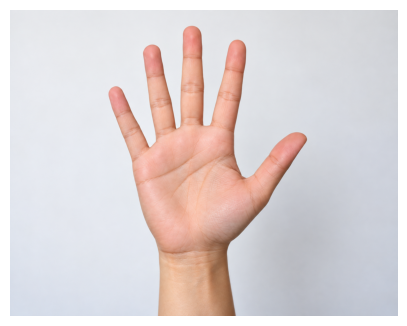

In [97]:
IMAGE_PATH = "../data/workshop_images/open_palm.png"

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

# OpenCV loads images in BGR format.
# Convert it to RGB for display.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

### 2.2 Detect Hand Landmarks

We will use the pretrained MediaPipe Hand Landmarker to extract
the hand's structure from our image.

Recall that MediaPipe returns **21 landmarks**, each containing
an `(x, y, z)` coordinate.

Run the following cell to see how many hands and landmarks are detected.

In [98]:
# Configure MediaPipe Hand Landmarker

MODEL_PATH = "hand_landmarker.task"

base_options = tasks.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = tasks.vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

landmarker = tasks.vision.HandLandmarker.create_from_options(
    options
)

In [99]:
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

result = landmarker.detect(mp_image) # detect hand landmarks in the image

print("Hands detected:", len(result.hand_landmarks))

Hands detected: 1


In [100]:
# additional check to ensure that hand landmarks are detected

if result.hand_landmarks:
    hand_landmarks = result.hand_landmarks[0]

    print("Number of landmarks:", len(hand_landmarks))
else:
    raise ValueError("No hand detected in the image.")

Number of landmarks: 21


### 2.3 Visualise the 21 Landmarks

In [101]:
HAND_CONNECTIONS = [
    # Thumb
    (0, 1), (1, 2), (2, 3), (3, 4),

    # Index finger
    (0, 5), (5, 6), (6, 7), (7, 8),

    # Middle finger
    (5, 9), (9, 10), (10, 11), (11, 12),

    # Ring finger
    (9, 13), (13, 14), (14, 15), (15, 16),

    # Pinky
    (13, 17), (17, 18), (18, 19), (19, 20),

    # Palm
    (0, 17),
]

In [102]:
def draw_hand_landmarks(image, hand_landmarks):
    output = image.copy()

    height, width, _ = output.shape
    points = []

    # Convert normalized coordinates to pixel coordinates
    for landmark in hand_landmarks:
        x = int(landmark.x * width)
        y = int(landmark.y * height)
        points.append((x, y))

    # Draw connections
    for start, end in HAND_CONNECTIONS:
        cv2.line(
            output,
            points[start],
            points[end],
            (255, 255, 255),
            2
        )

    # Draw landmarks
    for index, point in enumerate(points):
        cv2.circle(
            output,
            point,
            5,
            (0, 255, 0),
            -1
        )

        cv2.putText(
            output,
            str(index),
            (point[0] + 5, point[1] - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (0, 255, 0),
            1
        )

    return output

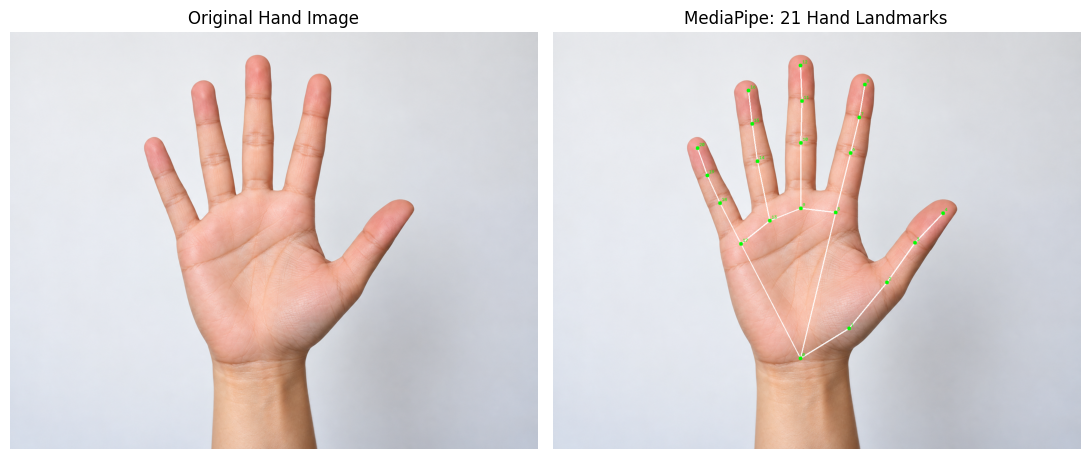

In [103]:
landmark_image = draw_hand_landmarks(
    image_rgb,
    hand_landmarks
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Original Hand Image")
axes[0].axis("off")

axes[1].imshow(landmark_image)
axes[1].set_title("MediaPipe: 21 Hand Landmarks")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 🔍 Observe the Output

Compare the original image with the detected landmarks.

- Do the landmarks follow the shape of the hand?
- Can you identify the wrist and fingertips?
- Which landmarks would be useful for distinguishing an open palm from a fist?

Notice that MediaPipe is extracting the **structure of the hand**,
rather than directly predicting the gesture.

### 2.4 What do the landmarks represent?

Each landmark corresponds to a specific part of the hand.

Some useful examples are:

| Landmark | Hand Part |
|---|---|
| `0` | Wrist |
| `4` | Thumb tip |
| `8` | Index fingertip |
| `12` | Middle fingertip |
| `16` | Ring fingertip |
| `20` | Pinky fingertip |

### 2.5 Inspect the Coordinates

Each landmark contains three normalized coordinates:

- **x** : horizontal position
- **y** : vertical position
- **z** : relative depth

Let's inspect the index fingertip (`landmark 8`).

In [104]:
index_tip = hand_landmarks[8]

print("Index fingertip (Landmark 8)")
print(f"x = {index_tip.x:.3f}")
print(f"y = {index_tip.y:.3f}")
print(f"z = {index_tip.z:.3f}")

Index fingertip (Landmark 8)
x = 0.591
y = 0.126
z = -0.134


In [105]:
# Let's inspect the first few raw landmark coordinates

for i in range(5):
    landmark = hand_landmarks[i]

    print(
        f"Landmark {i}: "
        f"x={landmark.x:.3f}, "
        f"y={landmark.y:.3f}, "
        f"z={landmark.z:.3f}"
    )

Landmark 0: x=0.469, y=0.783, z=0.000
Landmark 1: x=0.561, y=0.711, z=-0.059
Landmark 2: x=0.632, y=0.600, z=-0.082
Landmark 3: x=0.686, y=0.505, z=-0.100
Landmark 4: x=0.739, y=0.435, z=-0.118


### 🔍 Your Turn

Landmark `12` represents the **middle fingertip**.

Can you inspect its `(x, y, z)` coordinates?

In [106]:
# Replace ____ with the correct landmark number

# middle_tip = hand_landmarks[____]
middle_tip = hand_landmarks[12]

print(f"x = {middle_tip.x:.3f}")
print(f"y = {middle_tip.y:.3f}")
print(f"z = {middle_tip.z:.3f}")

x = 0.468
y = 0.080
z = -0.137


---

We have transformed:

**Hand Image → MediaPipe → 21 Hand Landmarks**

Each landmark provides numerical information about the hand's structure.

However, there is still a problem.

Imagine showing the exact same gesture at two different positions
in an image.

**Would the landmark coordinates remain the same?**

Let's investigate how we can represent the hand in a way that is
less dependent on its position in the image.

## 3. From Landmarks to Gesture Features

We now have 21 hand landmarks, each containing `(x, y, z)` coordinates.

This gives us **21 × 3 = 63 values** describing the hand.

But are the raw landmark coordinates the best representation for recognising gestures?

### 3.1 A Problem With Raw Coordinates

Imagine showing the same ✌️ gesture at two different positions in an image.

Although the gesture remains the same, its landmark coordinates change because the hand has moved.

**Our challenge:** How can we represent the hand's structure while reducing the influence of its position in the image?

In [107]:
# Simulate moving the same hand horizontally
original_x = hand_landmarks[8].x
shifted_x = original_x + 0.2

print(f"Original index fingertip x: {original_x:.3f}")
print(f"Shifted index fingertip x:  {shifted_x:.3f}")

Original index fingertip x: 0.591
Shifted index fingertip x:  0.791


(for demonstration only) \
The index fingertip's coordinate changed, but we haven't changed the gesture. So instead of focusing on its absolute position, let's describe its position relative to the hand itself.

### 3.2 Use the wrist as our reference point

To reduce the effect of hand position, we can represent every landmark relative to the **wrist (landmark 0)**.

For each landmark, we subtract the wrist's coordinates:

$x_{relative} = x_{landmark} - x_{wrist}$

$y_{relative} = y_{landmark} - y_{wrist}$

$z_{relative} = z_{landmark} - z_{wrist}$

This shifts the hand representation so that the wrist becomes our reference point.

The relative positions of the fingers and joints are preserved.

### 💻 Exercise 1: Create Wrist-Relative Features

Complete the feature extraction function so that every landmark is represented relative to the wrist.

The function should return a flattened list of 63 values:

`[x0, y0, z0, x1, y1, z1, ..., x20, y20, z20]`

**Hint:** Landmark `0` represents the wrist. Subtract its coordinates from each landmark.

In [108]:
def create_features(hand_landmarks):

    wrist = hand_landmarks[0]
    features = []

    for landmark in hand_landmarks:

        # # TODO: Make each coordinate relative to the wrist
        # relative_x = landmark.x - ________
        # relative_y = landmark.y - ________
        # relative_z = landmark.z - ________

         # SOLUTION
        relative_x = landmark.x - wrist.x
        relative_y = landmark.y - wrist.y
        relative_z = landmark.z - wrist.z

        features.extend([
            relative_x,
            relative_y,
            relative_z
        ])

    return features

### 3.4 Create the feature vector

In [109]:
features = create_features(hand_landmarks)

print("Number of features:", len(features))
print("\nFirst 4 landmarks:")

for i in range(4):
    x, y, z = features[i * 3 : i * 3 + 3]
    print(f"Landmark {i}: ({x:.3f}, {y:.3f}, {z:.3f})")

assert len(features) == 63
assert np.allclose(features[:3], [0, 0, 0])

print("\nFeature representation looks correct!")

Number of features: 63

First 4 landmarks:
Landmark 0: (0.000, 0.000, 0.000)
Landmark 1: (0.092, -0.072, -0.059)
Landmark 2: (0.164, -0.182, -0.082)
Landmark 3: (0.217, -0.277, -0.100)

Feature representation looks correct!


### 3.5 A Quick Check

Since all landmarks are now represented relative to the wrist, what should the wrist's own coordinates become?

Remember:

$x_{relative} = x_{landmark} - x_{wrist}$

For landmark `0`, the landmark itself **is the wrist**.

In [110]:
print("Wrist features:")
print(features[:3])

Wrist features:
[0.0, 0.0, 0.0]


---

We have transformed a hand image into a compact representation of its geometry:

**Hand Image → MediaPipe → 21 Landmarks → 63 Wrist-Relative Features**

This representation is less dependent on where the hand appears in the image.

However, wrist-relative coordinates do not automatically handle differences in hand size, rotation or camera angle.

Next, we'll see how these features were collected from multiple people to create our gesture dataset.

## 4. Meet the Gesture Dataset

We have successfully converted **one hand image into 63 wrist-relative landmark features**.

But recognising gestures requires more than one example!

Our workshop team collected hand gesture data from three different contributors using MediaPipe.

Each dataset contains:

- **63 features:** Wrist-relative landmark coordinates
- **Label:** The gesture being shown
- **Metadata:** Contributor, handedness and collection session

Each row represents one detected hand from a webcam frame.

Let's take a look at our collected data!

### 4.1 Load the Collected Data

In [111]:
member_a = pd.read_csv("../data/member_a_gestures.csv")
member_b = pd.read_csv("../data/member_b_gestures.csv")
member_c = pd.read_csv("../data/member_c_gestures.csv")

print("Member A:", member_a.shape)
print("Member B:", member_b.shape)
print("Member C:", member_c.shape)

Member A: (160, 67)
Member B: (160, 67)
Member C: (160, 67)


In [112]:
display(
    member_a[
        [
            "x0", "y0", "z0",
            "x8", "y8", "z8",
            "label", "handedness"
        ]
    ].head()
)

,x0,y0,z0,x8,y8,z8,label,handedness
0,0.0,0.0,0.0,0.162788,-0.450639,-0.081764,OPEN_PALM,RIGHT
1,0.0,0.0,0.0,0.162451,-0.452061,-0.080887,OPEN_PALM,RIGHT
2,0.0,0.0,0.0,0.159847,-0.452839,-0.081503,OPEN_PALM,RIGHT
3,0.0,0.0,0.0,0.066231,-0.514734,-0.086074,OPEN_PALM,RIGHT
4,0.0,0.0,0.0,0.022018,-0.522402,-0.099823,OPEN_PALM,RIGHT


Quick question to ask participants:\
why do you think x0, y0 and z0 are all zero? \
ans: because the wrist is the reference point from exercise 1

### 4.2 Can Our System Recognise a New Person?

A gesture recogniser should work on more than just the people whose hands were used during training.

To investigate this, we collected gesture examples from three different contributors.

We will use:

- **Members B + C:** Training data
- **Member A:** Held-out test data

Member A's data will not be used during training.

**Think about it:** Why might testing on a completely new person be more meaningful than randomly mixing frames from all three contributors?

In [113]:
member_a["label"].value_counts()

label
OPEN_PALM    40
FIST         40
PEACE        40
POINTING     40
Name: count, dtype: int64

Presenter Script:\
Earlier, we learned that one confident prediction doesn't necessarily mean a model is accurate. Now we have labelled examples from a completely new person, so we can actually evaluate how well our gesture recogniser generalises.\
(to connect back to Wei Tao's notebook)

### 4.3 Preparing Our Experiment

We will combine Members B and C into one training dataset.

Member A will remain separate for evaluation.

This ensures our classifier is tested on hand data from someone it has not encountered during training.

### 4.5 Why did we collect data from different people?

In [114]:
train_data = pd.concat(
    [member_b, member_c],
    ignore_index=True
)

test_data = member_a.copy()

print("Training samples:", len(train_data))
print("Held-out test samples:", len(test_data))

Training samples: 320
Held-out test samples: 160


Important note for presenter:\
Because our data collection script records multiple frames from the same contributor, those frames may be quite similar.

Holding out Member C helps avoid testing on near-duplicate frames from the training contributors. However, it still evaluates performance under your particular collection conditions, not across every possible person or environment.


We'll revisit that distinction when interpreting the results in Section 6.

## 5. Train the Gesture Classifier

Earlier, we used **MobileNetV2**, a pretrained CNN, to classify images without training it ourselves.

This time, we're doing something slightly different:

- **MediaPipe:** A pretrained CV model that extracts hand landmarks.
- **Our classifier:** A model that we will train to recognise gestures from those landmarks.

We will use a **Random Forest classifier** as a simple baseline.

Our focus is not the Random Forest algorithm itself, but how the visual features extracted from our CV pipeline can be used to recognise gestures.

### 5.1 Prepare Our Model Inputs

Recall that each hand is represented by **63 wrist-relative landmark features**.

We will use:

- `X`: The landmark features
- `y`: The gesture label

Metadata such as `member`, `handedness` and `session` will not be used as model inputs.

Our training set contains Members B and C, while Member A remains completely held out.

In [115]:
# select only the 63 landmarks coordinates
feature_columns = [
    coordinate
    for i in range(21)
    for coordinate in (f"x{i}", f"y{i}", f"z{i}")
]

# Training: Members B + C
X_train = train_data[feature_columns]
y_train = train_data["label"]

# Testing: Member A
X_test = test_data[feature_columns]
y_test = test_data["label"]

print("Number of features:", len(feature_columns))
print(f"Training samples: {len(X_train)}")
print(f"Held-out test samples: {len(X_test)}")

Number of features: 63
Training samples: 320
Held-out test samples: 160


### (ONLY FOR INSTRUCTOR TO CUE) 🤔 Think About It

Why are we keeping **all of Member A's samples** out of the training data?

Instead of asking:

> "Can the model recognise another frame similar to one it has already seen?"

we are asking a harder and more realistic question:

> **"Can the model recognise gestures from a person whose hand it has never seen before?"**

### 💻 Exercise 2: Train Our Gesture Classifier

We will use a Random Forest classifier (as our baseline model) to learn patterns in the hand-landmark features.

The classifier combines predictions from multiple decision trees to recognise different gestures.

**Your task:** Train the classifier using the landmark features and gesture labels from Members A and B.

**Hint:** Use `.fit(X_train, y_train)` to train a scikit-learn model.

In [116]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# TODO 2: Train the model using X_train and y_train
# model.fit(None, None)

# Solution
model.fit(X_train, y_train)

print("Gesture classifier trained successfully!")

Gesture classifier trained successfully!


----
We trained a gesture classifier using **wrist-relative hand-landmark features** from Members A and B.

Notice that our Random Forest classifier never directly received the original hand images.

Instead, it learned from the structured hand representation extracted using MediaPipe.

Our pipeline so far:

**Hand Image → MediaPipe → Landmarks → Features → Trained Gesture Classifier**

But training a classifier doesn't tell us how well it performs.

**Next question:** Can it recognise gestures from Member C, whose data it has never seen before?

## 6. Evaluate the Gesture Classifier

Earlier, when using MobileNetV2, we learned that a high prediction score on one image does not necessarily mean the model performs well overall.

Now that we have labelled test data, we can evaluate our own gesture classifier!

Remember:

- **Training:** Members A + B
- **Testing:** Member C (unseen during training)

Our question is:

> How accurately can our classifier recognise gestures from a new person?

[INSTRUCTOR]\
This section should be short but meaningful. Participants have trained their classifier using Members B and C, so now we want to answer:
Can our classifier recognise gestures from Member A, whose hand data was never used during training?

We'll also connect this to Wei Tao's earlier discussion about prediction scores versus model accuracy.

### 6.1 Make Predictions

We will now use our trained classifier to predict the gestures in Member C's dataset.

Unlike training, the model's parameters are not updated during prediction.

In [117]:
# Predict gestures for Member C
predictions = model.predict(X_test)

print("Number of predictions:", len(predictions))

Number of predictions: 160


### 6.2 How Accurate Is Our Classifier?

Accuracy measures the proportion of test samples classified correctly.

$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}$

Let's calculate the accuracy on our held-out participant.

In [118]:
accuracy = accuracy_score(y_test, predictions)

correct = (y_test.to_numpy() == predictions).sum()
total = len(y_test)

print(f"Correct predictions: {correct}/{total}")
print(f"Held-out participant accuracy: {accuracy:.1%}")

Correct predictions: 107/160
Held-out participant accuracy: 66.9%


[INSTRUCTOR] \
feel free to change from like A to B like swap around as the test set, then u will see very different result\
like if we use member c as test set then we will see a 99.4% accuracy\
Does 99.4% accuracy mean our classifier will recognise gestures correctly for everyone?

### 6.3 Which Gestures Were Confused?

Accuracy tells us how often the classifier is correct overall.

But it does not tell us **which gestures are being confused**.

A confusion matrix helps us see the predictions for each gesture class.

- Rows represent the actual gestures.
- Columns represent the predicted gestures.
- Values on the diagonal represent correct predictions.
- Values outside the diagonal represent mistakes.

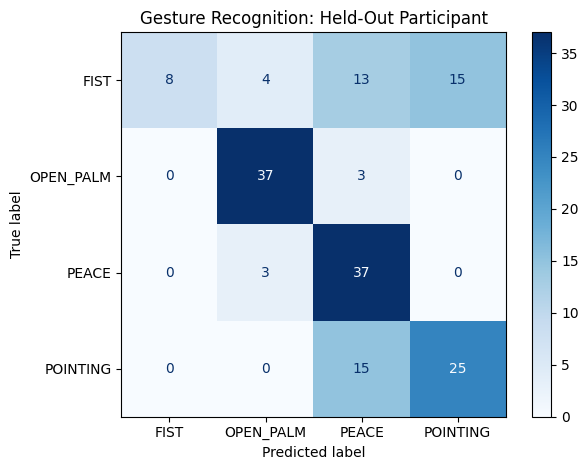

In [119]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    labels=model.classes_,
    cmap="Blues",
    values_format="d"
)

plt.title("Gesture Recognition: Held-Out Participant")
plt.tight_layout()
plt.show()

The important idea is that participants should inspect the off-diagonal cells rather than looking only at the overall accuracy.

Which gestures generalised well? Which were confused?

### 🔍 Pause and Think

Look at your accuracy and confusion matrix.

1. Which gestures were recognised correctly?
2. Were any gestures confused with one another?
3. Does good performance on Member C guarantee that our classifier will work on every new hand image?

**Remember:** Our evaluation uses landmark features collected under relatively controlled conditions.

What happens if we give the system a completely new image with different lighting, orientation or background?

---

So far, we have evaluated our classifier using pre-extracted landmark features stored in CSV files.

But a real Computer Vision application starts with an **image**, not a CSV row.

Our next challenge is to test the complete pipeline:

**New Hand Image**  
↓  
**MediaPipe Hand Landmarker**  
↓  
**21 Hand Landmarks**  
↓  
**Wrist-Relative Features**  
↓  
**Our Trained Gesture Classifier**  
↓  
**Gesture Prediction**

Let's see whether our system can recognise a gesture from an image it has never encountered before!

## 7. Test the Full CV Pipeline

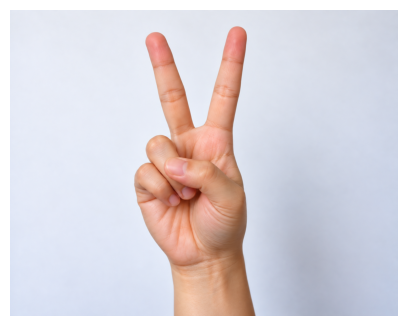

In [120]:
UNSEEN_IMAGE_PATH = "../data/workshop_images/peace.png"

unseen_image = cv2.imread(UNSEEN_IMAGE_PATH)
unseen_image_rgb = cv2.cvtColor(
    unseen_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5, 5))
plt.imshow(unseen_image_rgb)
plt.axis("off")
plt.show()

In [121]:
# create the landarker and detect hand landmarks in the unseen image
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=unseen_image_rgb
)

result = landmarker.detect(mp_image)

unseen_landmarks = result.hand_landmarks[0]

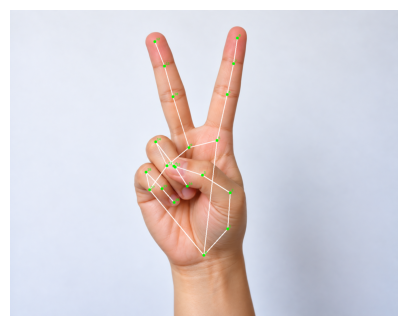

In [122]:
# Let's visualize the detected landmarks on the unseen image
landmark_image = draw_hand_landmarks(
    unseen_image_rgb,
    unseen_landmarks
)

plt.figure(figsize=(5, 5))
plt.imshow(landmark_image)
plt.axis("off")
plt.show()

Convert the landmarks into the SAME features.

In [123]:
unseen_features = create_features(
    unseen_landmarks
)

print("Number of features:", len(unseen_features))

Number of features: 63


In [124]:
X_unseen = pd.DataFrame(
    [unseen_features],
    columns=feature_columns
)

We start predict!

In [125]:
prediction = model.predict(X_unseen)[0]

print("Predicted gesture:", prediction)

Predicted gesture: PEACE


In [126]:
probabilities = model.predict_proba(X_unseen)[0]

for label, probability in zip(
    model.classes_,
    probabilities
):
    print(f"{label:12s}: {probability:.1%}")

FIST        : 0.0%
OPEN_PALM   : 8.0%
PEACE       : 92.0%
POINTING    : 0.0%


# YAYYYYYYYYYYYYY Our Final Combined Output

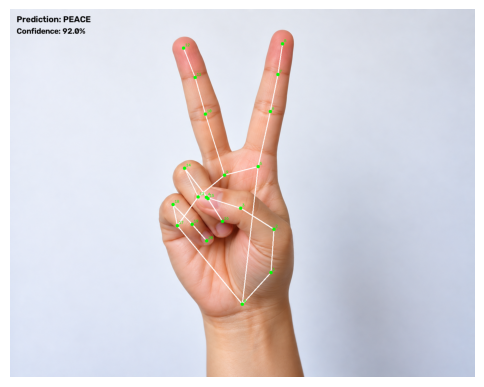

In [127]:
# Draw the detected landmarks
prediction_image = draw_hand_landmarks(
    unseen_image_rgb,
    unseen_landmarks
)

# Find the probability of the predicted class
predicted_index = list(model.classes_).index(prediction)
confidence = probabilities[predicted_index]

# Add prediction text to the image
cv2.putText(
    prediction_image,
    f"Prediction: {prediction}",
    (20, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.9,
    (0, 0, 0), # BGR text color
    2
)

cv2.putText(
    prediction_image,
    f"Confidence: {confidence:.1%}",
    (20, 75),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 0, 0),
    2
)

# Display final result
plt.figure(figsize=(6, 6))
plt.imshow(prediction_image)
plt.axis("off")
plt.show()

Feel free to try your own hand gesture picture as well!